Sensor Calibration using AI  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense


file_path = 'Measurement_summary.csv'
df = pd.read_csv(file_path)

display(df.head()) 
df.info()
print("\n Number of Missing Values per Column")
print(df.isnull().sum())

,Measurement date,Station code,Address,Latitude,Longitude,SO2,NO2,O3,CO,PM10,PM2.5
0,2017-01-01 00:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.004,0.059,0.002,1.2,73.0,57.0
1,2017-01-01 01:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.004,0.058,0.002,1.2,71.0,59.0
2,2017-01-01 02:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.004,0.056,0.002,1.2,70.0,59.0
3,2017-01-01 03:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.004,0.056,0.002,1.2,70.0,58.0
4,2017-01-01 04:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.003,0.051,0.002,1.2,69.0,61.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 647511 entries, 0 to 647510
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Measurement date  647511 non-null  object 
 1   Station code      647511 non-null  int64  
 2   Address           647511 non-null  object 
 3   Latitude          647511 non-null  float64
 4   Longitude         647511 non-null  float64
 5   SO2               647511 non-null  float64
 6   NO2               647511 non-null  float64
 7   O3                647511 non-null  float64
 8   CO                647511 non-null  float64
 9   PM10              647511 non-null  float64
 10  PM2.5             647511 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 54.3+ MB

 Number of Missing Values per Column
Measurement date    0
Station code        0
Address             0
Latitude            0
Longitude           0
SO2                 0
NO2                 0
O3        

In [ ]:
from sklearn.model_selection import train_test_split
#Ground truth values (x), these are the actual PM2.5 measurements from the dataset.
target_col = 'PM2.5' 
x_true = df[target_col].values
# Simulating the sensor drift and noise with linear drift and random noise.
np.random.seed(42)
noise= np.random.normal(0, 3, len(x_true)) # Random noise
drift_factor = 1.15 # Sensor reads 15% higher
offset= 5 #Constant offset for the sensor.

y_sensor = (x_true * drift_factor) + offset + noise
df['Sensor_Reading_Y'] = y_sensor
# Faulty sensor readings (y) are the input features, and the true PM2.5 values (x) are the target variable we want to predict.
X_features = df[['Sensor_Reading_Y']] 
y_target = df[target_col]             

# 5. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (518008, 1)
Testing data shape: (129503, 1)



Evaluating calibration algorithms...

--- Linear Regression Performance ---
Mean Squared Error (MSE): 6.81
R-squared (R2): 1.00

--- Random Forest Performance ---
Mean Squared Error (MSE): 9.46
R-squared (R2): 0.99



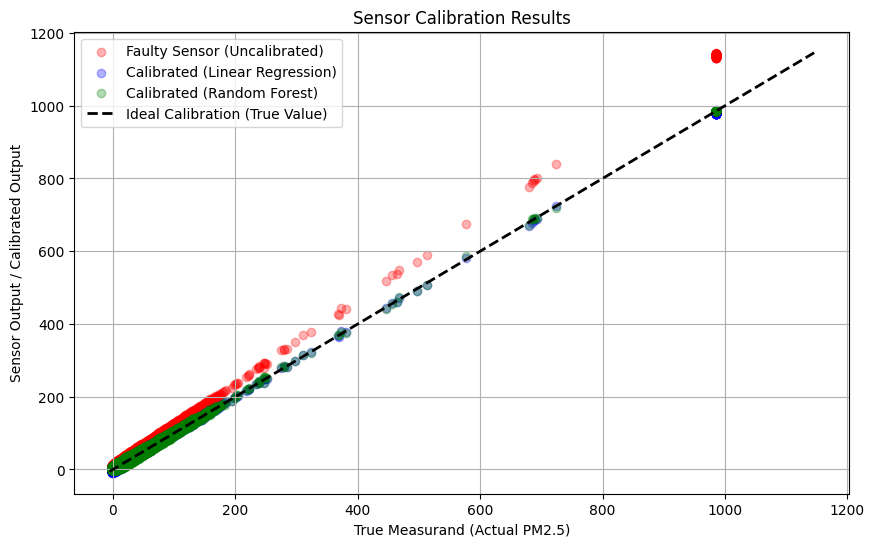

In [ ]:


linear_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the Linear Regression model
linear_model.fit(X_train, y_train)

# Train the Random Forest model
rf_model.fit(X_train, y_train)

# Make Predictions
y_pred_linear = linear_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Models
def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} Performance Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"R-squared (R2): {r2:.2f}\n")

print("\nEvaluating calibration algorithms...\n")
evaluate_model("Linear Regression", y_test, y_pred_linear)
evaluate_model("Random Forest", y_test, y_pred_rf)

# Visualizing the Calibration Results
plt.figure(figsize=(10, 6))

# Plot uncalibrated (faulty) sensor data
plt.scatter(y_test, X_test['Sensor_Reading_Y'], alpha=0.3, label='Faulty Sensor (Uncalibrated)', color='red')

# Plot calibrated data from models
plt.scatter(y_test, y_pred_linear, alpha=0.3, label='Calibrated (Linear Regression)', color='blue')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='Calibrated (Random Forest)', color='green')

# Ideal calibration line (y = x) where true value equals calibrated value
min_val = min(y_test.min(), X_test['Sensor_Reading_Y'].min())
max_val = max(y_test.max(), X_test['Sensor_Reading_Y'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal Calibration (True Value)')

# Some visual enhancements by AI.
plt.xlabel('True Measurand (Actual PM2.5)')
plt.ylabel('Sensor Output / Calibrated Output')
plt.title('Sensor Calibration Results')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# These models require scaled data for optimal performance and training stability.
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Since the dataset is huge, training standard SVR on all data will take too much time.
# We slice a representative sample of 20,000 rows for training the SVR model to ensure it runs in a reasonable time frame while still capturing the underlying patterns.
sample_size = 20000
X_train_sample = X_train[:sample_size]
y_train_sample = y_train[:sample_size]

# Scale features (X)
X_train_scaled = scaler_X.fit_transform(X_train_sample)
X_test_scaled = scaler_X.transform(X_test)

# Scale target (y) - we need to reshape it to 2D for the scaler and then flatten it back to 1D after scaling.
y_train_scaled = scaler_y.fit_transform(y_train_sample.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train_scaled)

# Make predictions adn try to match PM2.5 values by reversing the scaling.
y_pred_svr_scaled = svr_model.predict(X_test_scaled)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

X_train_rnn = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_rnn = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Building a simple sequential RNN model
rnn_model = Sequential()
rnn_model.add(SimpleRNN(32, activation='relu', input_shape=(1, 1)))
rnn_model.add(Dense(16, activation='relu'))
rnn_model.add(Dense(1)) 

rnn_model.compile(optimizer='adam', loss='mse')

# Train the RNN model
rnn_model.fit(X_train_rnn, y_train_scaled, epochs=10, batch_size=64, validation_split=0.1, verbose=1)

# Make predictions and reverse the scaling
y_pred_rnn_scaled = rnn_model.predict(X_test_rnn)
y_pred_rnn = scaler_y.inverse_transform(y_pred_rnn_scaled).ravel()


evaluate_model("Support Vector Regressor (SVR)", y_test, y_pred_svr)
evaluate_model("RNN Regressor", y_test, y_pred_rnn)

C:\Users\ataka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0573 - val_loss: 0.0035
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - val_loss: 0.0036
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - val_loss: 0.0036
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 9/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - val_loss: 0.0036
Epoch 10/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0036 - val_loss: 0.0035
4047/4047 ━━━━━━━━━━━━━━━━━━━━ 4s 820us/step
--- Support Vector Regressor (SVR) Performance ---
Mean Squared Error (MSE): 14.77
R-squared (